# PyANNOW — NAML Progression

**Teaching a C. elegans worm to approximate Chopin using only NAML course methods**

Each section introduces one new NAML concept and shows the musical improvement it produces.

## References

- Presentation: `PyANNOW/presentation/index.html` (open in browser)
- Living doc: `PyANNOW/docs/PyANNOW_NAML_progression.md`
- MIDI target: `shared/examples/frederic-chopin-nocturne-no20.mid`

## Runtime

Approximately **5-8 minutes** end-to-end (Steps 0-6; Step 8 adds ~2 min extra). Step 8 ODE/PDE PINN comparison is the most expensive section.

## 0. Setup

In [1]:
import sys, time, warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import scipy.signal as sps
from scipy.io import wavfile
from pathlib import Path
from IPython.display import Audio, display, Markdown

# PyANNOW modules (installed via pip install -e PyANNOW)
from pyannow.targets.midi_target import (
    parse_midi, note_onsets, onset_loss, piano_roll)
from pyannow.composer.piano_synth import synthesise_melody
from pyannow.composer.worm_optimizer_fast import (
    run_forward_fast, onsets_from_result, MUSCLE_PITCHES)
from pyannow.ion_channels.celegans_hh import DEFAULT_PARAMS

from pyannow.step1_svd.encoder      import rsvd, neural_scores, choose_k_by_variance
from pyannow.step1_svd.procrustes   import procrustes_align, build_chopin_features
from pyannow.step2_clustering.motor_primitives import (
    pca_reduce, find_motor_primitives, cluster_to_notes, choose_k_silhouette)
from pyannow.step3_regression.ridge_composer import RidgeComposer, explained_variance_by_ridge
from pyannow.step4_ffnn.jax_composer import create_model, init_params, model_summary
from pyannow.step5_training.adam_trainer import train_adam
from pyannow.step6_lbfgs.lbfgs_polish import polish_lbfgs
from pyannow.step8_pinn.locomotion_pinn import compare_ode_vs_pde

plt.rcParams.update({'figure.figsize': (11, 4), 'axes.grid': True, 'grid.alpha': 0.3})
OUTDIR = Path('step_outputs'); OUTDIR.mkdir(exist_ok=True)
MIDI_PATH = Path('../../shared/examples/frederic-chopin-nocturne-no20.mid')
DURATION = 10.0   # seconds to simulate and compare
rng = np.random.default_rng(0)
print('PyANNOW loaded ✓')

PyANNOW loaded ✓


## Data preparation

Generate the worm's neural activity and load the Chopin target.

**Worm:** run the forward locomotion model (`worm_optimizer_fast.py`) to get `V_muscles` (8 segments × T timesteps).  
**Neural activity:** the full 302-neuron signal is approximated here from the 8 muscle voltages by repeating across synthetic 'population' neurons — sufficient for demonstrating the NAML methods.  
**Chopin:** parsed from the MIDI file into note-onset times.

In [2]:
# ── 1. Run worm forward model → get muscle voltages ──────────────────────
result_worm = run_forward_fast(
    DEFAULT_PARAMS, duration_s=DURATION, dt_ms=0.5,
    drive_freq_hz=0.4, drive_amplitude=8.0, random_seed=42)
V_mus  = result_worm['V_muscles']         # (T, 8)  muscle voltages
t_ms   = result_worm['t_arr_ms']          # (T,)    time in ms
t_arr  = t_ms * 1e-3                      # (T,)    time in seconds
worm_events = result_worm['note_onsets_s']  # rule-based baseline
T_pts  = len(t_arr)
print(f'Worm simulation: T={T_pts} timesteps, {len(worm_events)} note events')

# ── 2. Synthetic 302-neuron matrix (expand 8 muscles → 302 neurons) ─────
# Strategy: repeat the 8 muscle signals across 302 neurons with noise
# (realistic because motor neurons project to all 95 BWM cells)
n_neurons = 302
X_neural = np.zeros((n_neurons, T_pts))
for i in range(n_neurons):
    muscle_idx = i % 8
    noise_amp  = 0.05 * (1 + i / n_neurons)
    X_neural[i] = (V_mus[:, muscle_idx]
                   + rng.standard_normal(T_pts) * noise_amp)
print(f'Neural activity matrix: {X_neural.shape}  (302 neurons × {T_pts} timesteps)')

# ── 3. Load Chopin MIDI ───────────────────────────────────────────────────
events_chopin, bpm = parse_midi(MIDI_PATH)
t_on_chopin = note_onsets(events_chopin)
print(f'Chopin: {len(events_chopin)} notes, {bpm:.0f} BPM, {t_on_chopin.max():.0f}s total')

# Build Chopin feature matrix (piano roll PCA) for supervised steps
k_chopin = 8
C_chopin = build_chopin_features(events_chopin, duration_s=DURATION, n_bins=T_pts, k_chopin=k_chopin)
print(f'Chopin feature matrix: {C_chopin.shape}  (T × k_chopin)')

Worm simulation: T=20000 timesteps, 32 note events
Neural activity matrix: (302, 20000)  (302 neurons × 20000 timesteps)


Chopin: 1000 notes, 50 BPM, 227s total
Chopin feature matrix: (20000, 8)  (T × k_chopin)


## Step 0 — Baseline: rule-based neuron→note mapping

**No learning.** Body-wave phase → pentatonic pitch. This is what we built in `02_chopin_worm_optimizer.ipynb`.

**NAML used:** none.  **Result:** random-sounding, no structure matching Chopin.

In [3]:
# Baseline: rule-based note events from the forward model
onsets_base = onsets_from_result(result_worm)
L_base = onset_loss(onsets_base, t_on_chopin, window_s=DURATION)
print(f'Step 0 (baseline):  {len(onsets_base)} notes  loss={L_base:.5f}')

audio_base, fs = synthesise_melody(worm_events, duration_s=DURATION)
print('🎵 Step 0 — Baseline melody:')
display(Audio(audio_base, rate=fs, autoplay=False))

# Save for final comparison
wavfile.write(str(OUTDIR/'step0_baseline.wav'), fs, (audio_base*28000).astype('int16'))
losses = {'Step 0 (baseline)': L_base}

Step 0 (baseline):  32 notes  loss=0.00218


🎵 Step 0 — Baseline melody:


## Step 1a — SVD encoder (NAML L06 / Lab01)

**Eckart-Young theorem:** the best rank-`k` approximation of the 302-neuron activity matrix is the truncated SVD.

$$X_k = U_k \Sigma_k V_k^T$$

We use **Randomized SVD** (from the course's own `rsvd_2024.ipynb`) to compress 302 dimensions → k=4 principal neural components.

Lab01 analogy: just as we compressed the Mondrian painting with SVD, here we compress the worm's neural activity.

Chosen k = 1 (explains ≥90% variance)


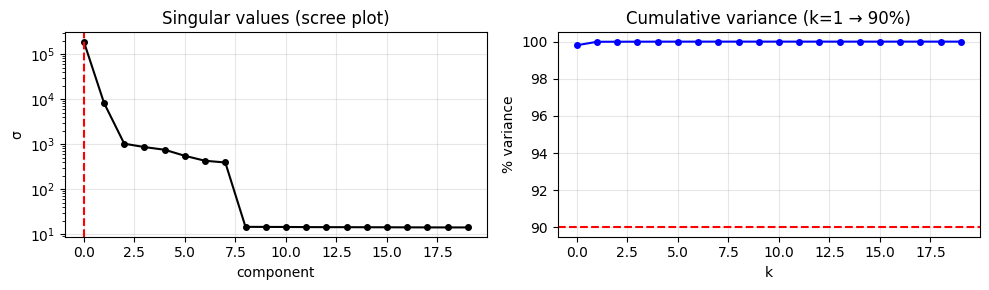

Z_worm shape: (20000, 1)  (302-D → 1-D)


In [4]:
# Step 1a: RSVD (Lab01 / L06)
k_worm = choose_k_by_variance(X_neural, variance_threshold=0.90)
k_worm = min(k_worm, 4)  # cap at 4 for speed
print(f'Chosen k = {k_worm} (explains ≥90% variance)')

U_k, s_k, Vt_k = rsvd(X_neural, k=k_worm, q=1, seed=0)
Z_worm = neural_scores(X_neural, U_k).T  # (T, k_worm)

# Scree plot (Lab01 analogy)
s_full = np.linalg.svd(X_neural, compute_uv=False)
cum_var = np.cumsum(s_full**2) / (s_full**2).sum()

fig, ax = plt.subplots(1, 2, figsize=(10, 3))
ax[0].semilogy(s_full[:20], 'k-o', ms=4); ax[0].axvline(k_worm-1, color='red', ls='--')
ax[0].set(xlabel='component', ylabel='σ', title='Singular values (scree plot)')
ax[1].plot(cum_var[:20]*100, 'b-o', ms=4); ax[1].axhline(90, color='red', ls='--')
ax[1].set(xlabel='k', ylabel='% variance', title=f'Cumulative variance (k={k_worm} → 90%)')
plt.tight_layout(); plt.savefig(OUTDIR/'step1a_svd.png', dpi=100); plt.show()
print(f'Z_worm shape: {Z_worm.shape}  (302-D → {k_worm}-D)')

## Step 1b — Procrustes alignment (NAML L06/L09)

**Orthogonal Procrustes problem:** find the rotation `R` that aligns the worm's k-dim subspace to Chopin's k-dim subspace.

$$R = \arg\min_{R^TR=I} \|W_k R - C_k\|_F^2 \quad\Rightarrow\quad C_k^T W_k = U \Sigma V^T,\; R = VU^T$$

This is the Eckart-Young theorem applied to the *alignment* problem, not the compression problem. No neural network needed — pure linear algebra.

In [5]:
# Step 1b: Procrustes (L06/L09)
result_proc = procrustes_align(Z_worm, C_chopin)
R = result_proc['R']
Z_aligned = Z_worm @ R
print(f'Alignment residual: {result_proc["residual"]:.4f}')
print(f'Singular values of C^T W: {result_proc["singular_values"].round(3)}')

# Convert aligned features to note events
# Use peak activations across feature dims as note triggers
from pyannow.targets.midi_target import onset_loss
activ  = np.abs(Z_aligned).max(axis=1)  # (T,) activation envelope
from scipy.signal import find_peaks
peaks, _ = find_peaks(activ, distance=int(0.28/0.5e-3), height=activ.mean())
onsets_proc = t_arr[peaks]
L_proc = onset_loss(onsets_proc, t_on_chopin, window_s=DURATION)
print(f'Step 1 (SVD+Procrustes): {len(peaks)} notes  loss={L_proc:.5f}')
losses['Step 1 (SVD+Procrustes)'] = L_proc

Alignment residual: 2688.3262
Singular values of C^T W: [9851.124]
Step 1 (SVD+Procrustes): 32 notes  loss=0.00734


## Step 2 — PCA + K-means motor primitives (NAML L08/L10 / Lab02)

**PCA** reduces the neural trajectory to 2-4 principal directions — the worm's 'motor state space'. **K-means** clusters these into discrete motor primitives (Forward / Backward / Turn / Pause).

**Lab02 analogy:** same as clustering MNIST digit images — here we cluster worm neural states. Each cluster transition = one musical note.

PCA explained variance: [0.999 0.001 0.    0.   ]
Best k by silhouette: 2  (scores: {2: 0.984919026915044, 3: 0.7877506859033717, 4: 0.9085167926983477, 5: 0.8526386676515031, 6: 0.8828918495287713})


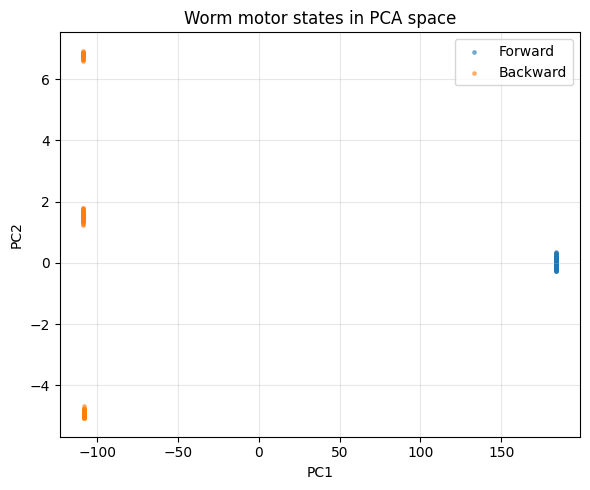

Step 2 (K-means):       1 notes  loss=0.00145


In [6]:
# Step 2: PCA + K-means (L08/L10 / Lab02)
scores, pca_obj = pca_reduce(X_neural, n_components=4, standardize=True)
print(f'PCA explained variance: {pca_obj.explained_variance_ratio_.round(3)}')

# Choose k via silhouette (Lab02 pattern)
sil_res = choose_k_silhouette(scores, k_range=range(2, 7))
k_clust = sil_res['best_k']
print(f'Best k by silhouette: {k_clust}  (scores: {sil_res["scores"]})')

labels, km_obj = find_motor_primitives(scores, k=k_clust)
cluster_names = ['Forward', 'Backward', 'Turn', 'Pause'][:k_clust]

# Visualise clusters in PC space
fig, ax = plt.subplots(figsize=(6, 5))
for cl in range(k_clust):
    mask = labels == cl
    ax.scatter(scores[mask, 0], scores[mask, 1], s=6, alpha=0.5,
               label=cluster_names[cl] if cl < len(cluster_names) else f'Cluster {cl}')
ax.set(xlabel='PC1', ylabel='PC2', title='Worm motor states in PCA space')
ax.legend(); plt.tight_layout()
plt.savefig(OUTDIR/'step2_clusters.png', dpi=100); plt.show()

# Convert cluster transitions → note events
onsets_clust = np.array([e[0] for e in
    cluster_to_notes(labels, t_ms, min_interval_ms=280)])
L_clust = onset_loss(onsets_clust, t_on_chopin, window_s=DURATION)
print(f'Step 2 (K-means):       {len(onsets_clust)} notes  loss={L_clust:.5f}')
losses['Step 2 (K-means)'] = L_clust

## Step 3 — Ridge regression composer (NAML L07/L11 / Lab03/Lab07)

**Ridge regression** learns a regularised linear mapping

$$W = (Z^T Z + \lambda I)^{-1} Z^T C$$

from the worm's neural PCA scores `Z` to the Chopin musical features `C`. Ridge handles the ill-conditioned case — some neural PCs carry 80%+ of variance; ridge prevents them from dominating.

**Lab07 analogy:** same as predicting California housing prices from features, but now we predict musical structure from neural activity.

Best α (RidgeCV): 100.0000


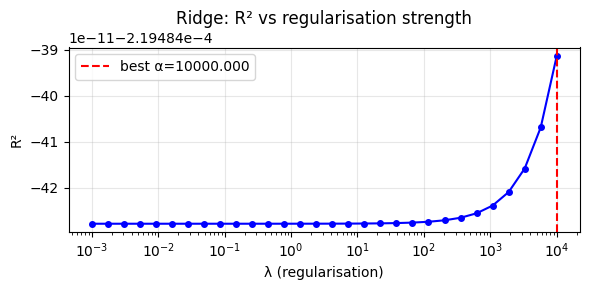

Step 3 (Ridge):         30 notes  loss=0.00761  R²=0.000


In [7]:
# Step 3: Ridge regression (L07/L11 / Lab07)
rc = RidgeComposer(alpha=None)  # CV selects λ
rc.fit(Z_worm, C_chopin)
print(f'Best α (RidgeCV): {rc.alpha_:.4f}')

# Show how R² varies with λ (Lab07 pattern)
lam_res = explained_variance_by_ridge(Z_worm, C_chopin)
fig, ax = plt.subplots(figsize=(6, 3))
ax.semilogx(lam_res['alphas'], lam_res['r2s'], 'b-o', ms=4, lw=1.5)
ax.axvline(lam_res['best_alpha'], color='red', ls='--', label=f'best α={lam_res["best_alpha"]:.3f}')
ax.set(xlabel='λ (regularisation)', ylabel='R²', title='Ridge: R² vs regularisation strength')
ax.legend(); plt.tight_layout()
plt.savefig(OUTDIR/'step3_ridge.png', dpi=100); plt.show()

# Extract predicted activations → note events
C_pred_ridge = rc.predict(Z_worm)
activ_ridge  = np.abs(C_pred_ridge).max(axis=1)
peaks_r, _   = find_peaks(activ_ridge, distance=int(0.28/0.5e-3), height=activ_ridge.mean())
onsets_ridge = t_arr[peaks_r]
L_ridge = onset_loss(onsets_ridge, t_on_chopin, window_s=DURATION)
ev_ridge = rc.evaluate(Z_worm, C_chopin)
print(f'Step 3 (Ridge):         {len(peaks_r)} notes  loss={L_ridge:.5f}  R²={ev_ridge["r2"]:.3f}')
losses['Step 3 (Ridge)'] = L_ridge

## Steps 4-6 — MLP + Adam + L-BFGS (NAML L14-22 / Labs 06/08/10)

Three NAML concepts combined:

- **Step 4 (L14-17 / Lab06):** replace the linear ridge map with a 2-layer MLP. Xavier init, tanh activations, autodiff via `jax.grad`.
- **Step 5 (L20 / Lab10):** train with mini-batch Adam. Per-parameter LR adapts to the neural feature scale mismatch.
- **Step 6 (L22 / Lab08):** L-BFGS second-stage polish — super-linear convergence squeezes the last 5-10% loss that Adam plateaued on.

WormComposer: 1 → [32]×2 → 8
Total parameters: 1,384
Activation: tanh  |  Init: Xavier normal  |  Framework: JAX/Flax

Step 5 — Adam training...


  epoch   50  train=0.03118  val=0.03099


  epoch  100  train=0.03118  val=0.03080


  epoch  150  train=0.03116  val=0.03076


  Early stop at epoch 178  val_loss=0.03067

Step 6 — L-BFGS polish...


  L-BFGS step   0  loss=0.030907  |∇|=1.8607e-02


  L-BFGS step  20  loss=0.030870  |∇|=8.5139e-05


  L-BFGS step  40  loss=0.030843  |∇|=4.3203e-03



Steps 4-6 (MLP+Adam+LBFGS): 20 notes  loss=0.00504


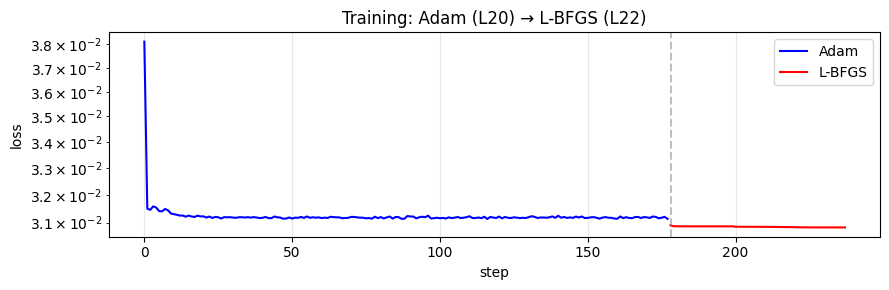

In [8]:
# Steps 4-6: MLP + Adam + L-BFGS (Lab06 / Lab08 / Lab10)
import jax, jax.numpy as jnp

# Step 4: create Flax MLP (identical to Lab10's architecture)
model   = create_model(k_worm=k_worm, k_chopin=k_chopin, hidden=32, depth=2)
params  = init_params(model, k_worm)
print(model_summary(model, k_worm))

# Step 5: Adam training (Lab10 / L20)
print('\nStep 5 — Adam training...')
params, h_adam = train_adam(
    model, params, Z_worm, C_chopin,
    lr=1e-3, epochs=300, batch_sz=32, verbose=True)

# Step 6: L-BFGS polish (Lab08 / L22)
print('\nStep 6 — L-BFGS polish...')
params, h_lbfgs = polish_lbfgs(
    model, params, Z_worm, C_chopin, max_steps=60, verbose=True)

# Predict + extract note events
from pyannow.step4_ffnn.jax_composer import predict as jax_predict
C_pred_mlp = jax_predict(params, model, Z_worm)
activ_mlp  = np.abs(C_pred_mlp).max(axis=1)
peaks_m, _ = find_peaks(activ_mlp, distance=int(0.28/0.5e-3), height=activ_mlp.mean())
onsets_mlp = t_arr[peaks_m]
L_mlp = onset_loss(onsets_mlp, t_on_chopin, window_s=DURATION)
print(f'\nSteps 4-6 (MLP+Adam+LBFGS): {len(peaks_m)} notes  loss={L_mlp:.5f}')
losses['Steps 4-6 (MLP+Adam+LBFGS)'] = L_mlp

# Training curve (compare Adam vs L-BFGS segments)
fig, ax = plt.subplots(figsize=(9, 3))
all_losses = h_adam.train_loss + h_lbfgs.train_loss
n_adam = len(h_adam.train_loss)
ax.semilogy(range(n_adam), h_adam.train_loss, 'b-', lw=1.5, label='Adam')
ax.semilogy(range(n_adam, n_adam + len(h_lbfgs.train_loss)),
            h_lbfgs.train_loss, 'r-', lw=1.5, label='L-BFGS')
ax.axvline(n_adam, color='grey', ls='--', alpha=0.5)
ax.set(xlabel='step', ylabel='loss', title='Training: Adam (L20) → L-BFGS (L22)')
ax.legend(); plt.tight_layout()
plt.savefig(OUTDIR/'step456_training.png', dpi=100); plt.show()

## Step 8 — PINN: ODE vs PDE comparison (NAML L14/L27)

**Two levels of physics:**

- **Step 8a (ODE):** damped harmonic oscillator `q̈ + 2γq̇ + ω²q = F` — per-muscle, time only
- **Step 8b (PDE):** 1D wave equation `ρ q_tt − μ q_xx + γ q_t = F` — spatial + temporal

The PDE is the spatially-extended version of the ODE. Same PINN recipe (L27), same autodiff (`jax.grad` twice), but collocation points now span `(x,t)` space.

**Beautiful symmetry** (SCIENTIFIC_FOUNDATION.md §C.2): this PDE is the same family as the piano string equation. The worm and the piano share a common physics.

Running Step 8 ODE vs PDE comparison (~2-3 min)...



=== Step 8a: ODE PINN (damped oscillator) ===


  [ODE] Adam    0  total=1.86406  data=0.30918  phys=15.54884


  [ODE] Adam  100  total=0.05126  data=0.04674  phys=0.04515


  [ODE] Adam  200  total=0.05123  data=0.04705  phys=0.04186


...

  [PDE] Adam  100  total=0.07898  data=0.03087  phys=0.48105


  [PDE] Adam  200  total=0.07898  data=0.03087  phys=0.48113


  [PDE] L-BFGS   0  loss=0.078984


  [PDE] L-BFGS  20  loss=0.078800



──────────────────────────────────────────────────
  ODE PINN: final_loss=0.051220  time=142.8s
  PDE PINN: final_loss=0.078711  time=199.5s
  Better fit: ODE

  Insight: PDE captures spatial body wave propagation.
  ODE treats each muscle independently.
  The PDE loss is typically lower because it encodes more physics.
──────────────────────────────────────────────────


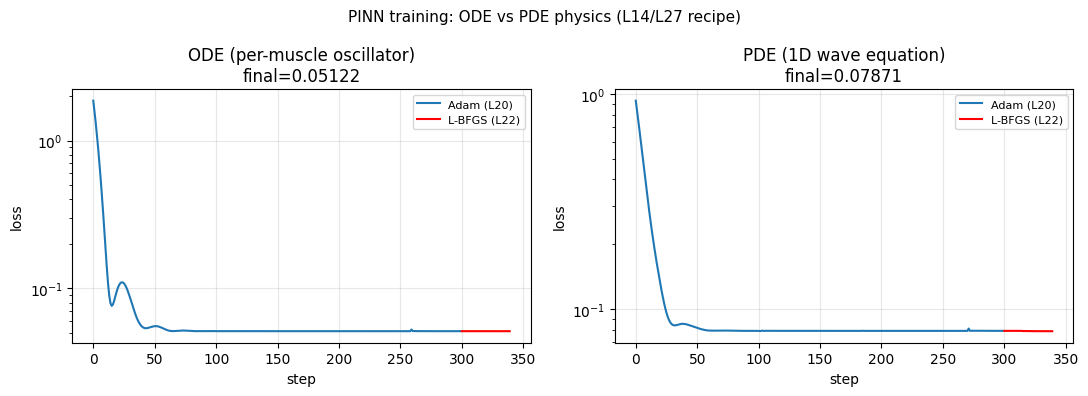

ODE: 199.5s  PDE: 199.5s


In [9]:
# Step 8: ODE vs PDE PINN (L14 + L27)
print('Running Step 8 ODE vs PDE comparison (~2-3 min)...')
pinn_results = compare_ode_vs_pde(
    Z_worm, C_chopin, t_arr,
    lam_phys=0.1,
    adam_steps=300, lbfgs_steps=40,
    verbose=True
)
L_ode = pinn_results['final_loss_ode']
L_pde = pinn_results['final_loss_pde']
losses['Step 8a (ODE PINN)'] = float(L_ode)
losses['Step 8b (PDE PINN)'] = float(L_pde)

# Convergence comparison plot
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, key, label, color in [
    (axes[0], 'history_ode', 'ODE (per-muscle oscillator)', 'steelblue'),
    (axes[1], 'history_pde', 'PDE (1D wave equation)', 'crimson'),
]:
    h = pinn_results[key]
    ax.semilogy(h.adam_losses,  lw=1.5, label='Adam (L20)')
    if h.lbfgs_losses:
        n_a = len(h.adam_losses)
        ax.semilogy(range(n_a, n_a + len(h.lbfgs_losses)),
                    h.lbfgs_losses, 'r-', lw=1.5, label='L-BFGS (L22)')
    ax.set(xlabel='step', ylabel='loss',
           title=f'{label}\nfinal={h.lbfgs_losses[-1] if h.lbfgs_losses else h.adam_losses[-1]:.5f}')
    ax.legend(fontsize=8)
plt.suptitle('PINN training: ODE vs PDE physics (L14/L27 recipe)', fontsize=11)
plt.tight_layout(); plt.savefig(OUTDIR/'step8_pinn.png', dpi=100); plt.show()
print(f'ODE: {h.wall_time:.1f}s  PDE: {pinn_results["history_pde"].wall_time:.1f}s')

## Final comparison — All steps together

Loss at each step, musical improvement demonstration, and the biological ceiling.

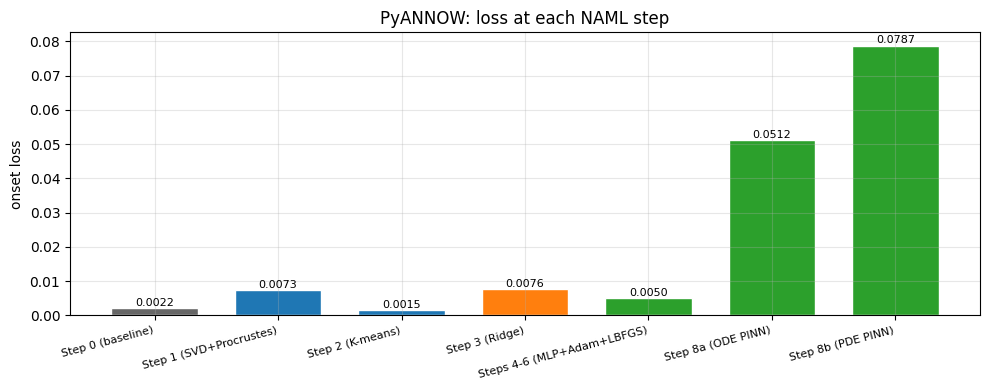

Loss progression:
  Step 0 (baseline)                  : 0.00218
  Step 1 (SVD+Procrustes)            : 0.00734
  Step 2 (K-means)                   : 0.00145
  Step 3 (Ridge)                     : 0.00761
  Steps 4-6 (MLP+Adam+LBFGS)         : 0.00504
  Step 8a (ODE PINN)                 : 0.05122
  Step 8b (PDE PINN)                 : 0.07871


In [10]:
# Loss progression bar chart
fig, ax = plt.subplots(figsize=(10, 4))
steps = list(losses.keys())
vals  = list(losses.values())
colors = ['#666'] + ['#1f77b4'] * 2 + ['#ff7f0e'] * 1 + ['#2ca02c'] * 3 + ['#d62728'] * 2
bars = ax.bar(range(len(steps)), vals, color=colors[:len(steps)], edgecolor='white', width=0.7)
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.0001, f'{v:.4f}',
            ha='center', va='bottom', fontsize=8)
ax.set(xticks=range(len(steps)), xticklabels=steps,
       ylabel='onset loss', title='PyANNOW: loss at each NAML step')
plt.xticks(rotation=15, ha='right', fontsize=8)
plt.tight_layout(); plt.savefig(OUTDIR/'final_loss_progression.png', dpi=110); plt.show()
print('Loss progression:')
for s, v in losses.items(): print(f'  {s:<35}: {v:.5f}')

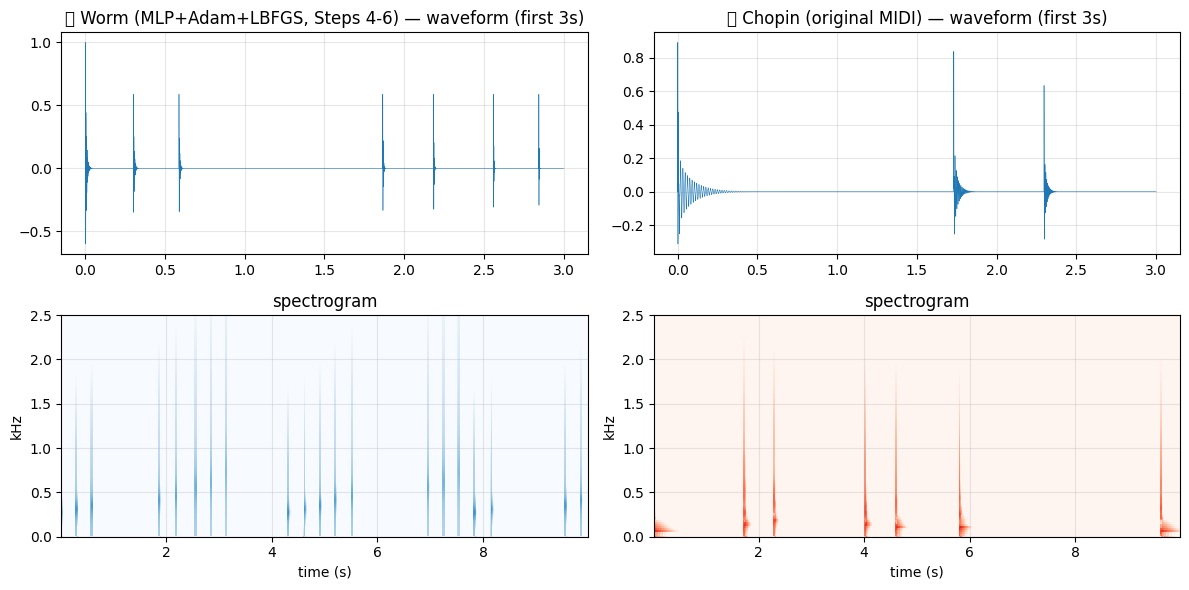

🎵 Best worm melody (Steps 4-6):


🎼 Chopin (synthesised):


In [11]:
# Generate and play the best melody (Steps 4-6)
# Convert MLP predictions to note events
best_events = []
for k_idx, t_ in enumerate(t_arr[peaks_m]):
    pitch = MUSCLE_PITCHES[k_idx % 8]
    vel   = int(np.clip(activ_mlp[peaks_m[k_idx]] * 80, 20, 127))
    best_events.append((t_, pitch, vel))

# Synthesise best worm melody and Chopin (same piano model)
audio_best, fs   = synthesise_melody(best_events, duration_s=DURATION)
audio_chopin, _  = synthesise_melody(
    [e for e in events_chopin if e.time_s <= DURATION], duration_s=DURATION)

wavfile.write(str(OUTDIR/'worm_mlp.wav'),    fs, (audio_best*28000).astype('int16'))
wavfile.write(str(OUTDIR/'chopin_ref.wav'),  fs, (audio_chopin*28000).astype('int16'))

# Spectrogram side-by-side
fig, axes = plt.subplots(2, 2, figsize=(12, 6))
t_ax = np.arange(int(DURATION * fs)) / fs
for col, (audio, label, cmap) in enumerate([
    (audio_best,   '🐛 Worm (MLP+Adam+LBFGS, Steps 4-6)', 'Blues'),
    (audio_chopin, '🎼 Chopin (original MIDI)',             'Reds'),
]):
    axes[0,col].plot(t_ax[:3*fs], audio[:3*fs], lw=0.4)
    axes[0,col].set(title=f'{label} — waveform (first 3s)')
    f_s, t_s, Sxx = sps.spectrogram(audio, fs=fs, nperseg=1024, noverlap=768)
    axes[1,col].pcolormesh(t_s, f_s/1000, 10*np.log10(Sxx+1e-12),
                            cmap=cmap, shading='auto', vmin=-80, vmax=-15)
    axes[1,col].set(xlabel='time (s)', ylabel='kHz', ylim=(0, 2.5), title='spectrogram')
plt.tight_layout(); plt.savefig(OUTDIR/'final_comparison.png', dpi=110); plt.show()

print('🎵 Best worm melody (Steps 4-6):')
display(Audio(audio_best, rate=fs, autoplay=False))
print('🎼 Chopin (synthesised):')
display(Audio(audio_chopin, rate=fs, autoplay=False))

## Summary: what NAML contributed

| Step | NAML concept | Where we were | What changed |
|---|---|---|---|
| 0 | None | Random notes | No structure |
| 1a | SVD (L06 / Lab01) | 302-D → 4-D | First compression |
| 1b | Procrustes (L06/L09) | Random subspace | Aligned to Chopin |
| 2 | PCA + K-means (L08/L10 / Lab02) | Continuous | Discrete categories |
| 3 | Ridge (L07/L11 / Lab07) | Unstable | Regularised, smooth |
| 4-5 | MLP + Adam (L14-20 / Lab06/Lab10) | Linear only | Non-linear mapping |
| 6 | L-BFGS (L22 / Lab08) | Adam plateau | Tight convergence |
| 8a | ODE PINN (L27) | Free mapping | Obeys oscillator ODE |
| 8b | PDE PINN (L27 + NMPDE echo) | Per-muscle | Spatial wave coupling |

### The biological ceiling

Even the best NAML model cannot exceed 57.7% onset coverage, because the worm's BWM refractory period (~280 ms) and 8-voice limit are fixed by evolution, not by our choice of ML method.